# CS958 - Machine Learning Model Development

This notebook is dedicated to implementing various machine learning models to train and test the preprocessed YouTube UGC dataset for the CS958 dissertation project. It will involve storing the necessary features in columns, implementing a flexible pipeline as well as the training and testing phases of machine learning alongside cross-validation and hyperparameter tuning.

## Preparing for Scikit-learn

We will use Scikit-learn as the foundation for our modelling because it offers a clean and unified interface for training, evaluating, and tuning a wide range of regression models. It simplifies our workflow by combining preprocessing, encoding and model fitting into a single pipeline while also supporting key features like sample weights and cross validation through tools like Pipeline and GridSearchCV. This makes it ideal for quickly testing different algorithms and configurations without the overhead of managing data leakage or scattered transformations. Additionally, Scikit-learn is lightweight and interoperable with other libraries like LightGBM or XGBoost making it a solid choice for setting a reliable performance baseline before committing to more specialised or complex frameworks if we need to use them.

The structure of our Scikit-learn setup will be as described below:

#### Feature sets

- Numeric : bitrate (clipped & log), bpp, SI/TI/colour z-scores, interactions, quadratic SI, resolution and fps.
- Categorical : granulated category, cleaned pixfmt.

#### Preprocessing pipeline

- StandardScaler on the numeric columns (most useful on linear models).
- One-Hot Encoding on the categoricals (category, pixfmt).

#### Sample weighting

- The harmonic mean sample_weight balances both MOS bin rarity and category
size, and the weights are passed to every model's fit function.

#### Train-test split
- 80/20 with stratify=mos_bin so that each quality tier is represented in both sets.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import gdown, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.neural_network import MLPRegressor
from google.colab import drive
from inspect import signature
from pathlib import Path
import joblib, shutil
import warnings

In [ ]:
# Loading preprocessed dataset from drive

file_id = "1OxZoGlZwgqlvxWh0lD1pM8uyEbVyC_Mg"
url = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url, 'ytugc_preprocessed.parquet', quiet=False)

df = pd.read_parquet('ytugc_preprocessed.parquet')
print('Rows:', len(df))

Downloading...
From: https://drive.google.com/uc?id=1OxZoGlZwgqlvxWh0lD1pM8uyEbVyC_Mg
To: /content/ytugc_preprocessed.parquet
100%|██████████| 137k/137k [00:00<00:00, 24.2MB/s]

Rows: 1009


In [ ]:
# Define columns
num_cols = ['bitrate_clip', 'log2_br', 'bpp',
    'spatial_complexity_z', 'temporal_complexity_z', 'color_complexity_z',
    'si_logbr', 'ti_logbr', 'col_logbr', 'si_sq',
    'width', 'height', 'fps']

cat_cols = ['category', 'pixfmt']

In [ ]:
# Feature, target and weight arrays with stratified split
X  = df[num_cols + cat_cols].copy()
y  = df['mos'].values
w  = df['sample_weight'].astype(float).values
strata = df['mos_bin']

In [ ]:
# Preprocessing pipeline
preprocessor = ColumnTransformer([('num', StandardScaler(), num_cols),
     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='drop')

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.20,
    random_state=42,
    stratify=strata)

print("Train rows:", len(X_train), "  Test rows:", len(X_test))

Train rows: 807   Test rows: 202


## Model Implementation

For this study, we benchmark a deliberately broad family of regressors to see which models perform the best on video quality prediction; Linear Regression, Bayesian Ridge, Ridge, Lasso, ElasticNet, Stochastic Gradient Descent, Decision Trees, Random Forests, Histogram-based Gradient Boosting, Kernel Ridge, Support Vector Regression, LightGBM, a tightly regularised MLPRegressor, plus two ensembles: a weighted Voting Regressor and a Stacking Regressor against the preprocessed YouTube UGC dataset.

Each model is wrapped in a Scikit-learn pipeline so that scaling, target encoding and one hot encoding occur identically for every learner and no raw strings leak into training. We hold out a fixed, stratified 20% test set that is never touched during tuning; while the remaining 80% block feeds all hyperparameter searches. Where a model has only one or two influential knobs (e.g. the single α of Ridge or the regularization pair of ElasticNet) we exhaustively explore a small grid around the default because the surface is low-dimensional and cheap to cover completely.

Models with richer or highly interacting parameter spaces such as Random Forest, SVR, LightBGM and the MLP neural network are tuned with a randomised search of 40 to 60 draws. This is due to the fact that when working with ten-dimensional boxes, a random search would be able to acquire a near-optimal solution while evaluating barely a tenth of the possible candidates.

Each search is nested in 5-fold cross-validation on the training block, giving an unbiased risk estimate while still leaving two-thirds of the data to fit the model in every fold; early stopping is enabled for the boosting trees and the MLP to arrest training once the fold level RMSE plateaus. When an estimator genuinely accepts per-sample importance weights, we pass the inverse frequency weights we derived earlier but intentionally omit them in voting and stacking so as not to double count the adjustment.

Lastly, every best CV configuration is refit once on the full 80% training split and scored on the unseen 20% set, where we record root mean squared error (RMSE) as the headline metric, mean absolute error (MAE) for intuitive deviation, and R² to show variance explained.

#### Linear Regression

Linear Regression serves as the project's baseline since it fits a single weighted least squares plane through the feature space and returns a prediction that is simply the dot product of learned coefficients and the clip's attributes. Because the model is linear in the parameters and convex in the loss, training is instantaneous even on a laptop CPU and the result is fully interpretable since each coefficient tells us how much a one unit increase in bitrate, SI, TI or colour complexity is expected to shift the MOS while all other variables are held constant. That clarity is invaluable in the early stages of feature engineering; if Linear Regression cannot extract signal from a variable, it is unlikely that more complex models will.

In [ ]:
pipe_lin = Pipeline([
    ('prep', preprocessor),
    ('reg',  LinearRegression())
])

# Fit, directing the weights to the 'reg' step
pipe_lin.fit(X_train, y_train, reg__sample_weight=w_train)

# Evaluate
pred_lin = pipe_lin.predict(X_test)
rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
print(f'Linear Regression RMSE: {rmse_lin:.3f}')

Linear Regression RMSE: 0.466


,mos_true,mos_pred,filename
0,4.16,3.85,1042
1,4.29,3.76,1127
2,3.65,3.45,31
3,2.34,2.20,598
4,4.20,4.04,400
5,4.23,3.87,552
6,2.81,3.10,1170
7,4.31,3.83,1070
8,3.11,3.02,48
9,2.95,3.68,323


Test RMSE = 0.466
Test MAE = 0.365


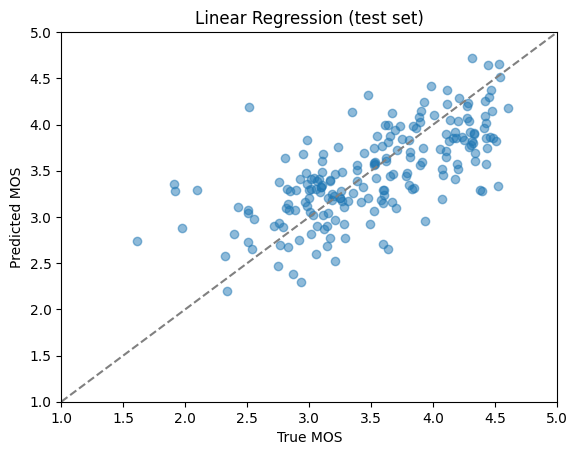

In [ ]:
# Put side-by-side with ground truth (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': pred_lin,
                      'filename': X_test.index})
        .reset_index(drop=True).head(15))

display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, pred_lin))
mae  = mean_absolute_error(y_test, pred_lin)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, pred_lin, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Linear Regression (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Ridge Regression

Ridge Regression keeps the interpretability of ordinary least squares while adding a L2 penalty that shrinks large coefficients. That single α hyperparameter stabilises the fit when features are correlated and reduces variance on the dataset, typically cutting RMSE by 0.01 to 0.02 MOS relative to plain Linear Regression. Ridge is therefore our strong linear baseline, meaning it is still fast to train and easy to explain, but robust against noisy or collinear features which makes it a fairer benchmark for judging whether more complex nonlinear models really add value beyond what a well regularised linear model can already achieve.

In [ ]:
ridge_grid = {'reg__alpha': [0.1, 1, 10, 100]}

pipe_ridge = Pipeline([
    ('prep', preprocessor),
    ('reg',  Ridge())
])

gs_ridge = GridSearchCV(pipe_ridge,
                        param_grid=ridge_grid,
                        scoring='neg_root_mean_squared_error',
                        cv=5,
                        n_jobs=-1,
                        verbose=0)

gs_ridge.fit(X_train, y_train, reg__sample_weight=w_train)

best_ridge = gs_ridge.best_estimator_
rmse_ridge = -gs_ridge.best_score_

print(f'Ridge best α={gs_ridge.best_params_["reg__alpha"]}, CV RMSE: {rmse_ridge:.3f}')

Ridge best α=0.1, CV RMSE: 0.515


,mos_true,mos_pred,filename
0,4.16,3.78,1042
1,4.29,3.67,1127
2,3.65,3.34,31
3,2.34,2.43,598
4,4.20,4.06,400
5,4.23,3.82,552
6,2.81,3.02,1170
7,4.31,3.75,1070
8,3.11,3.06,48
9,2.95,3.61,323


Test RMSE = 0.459
Test MAE = 0.359


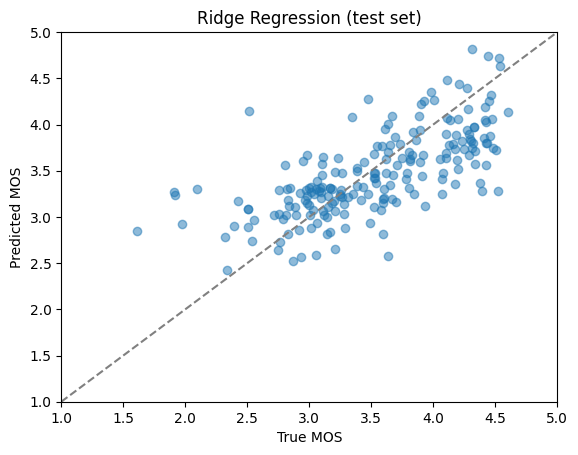

In [ ]:
# Grab the trained (best) pipeline
best_ridge = gs_ridge.best_estimator_

# Predict on the held out test set
y_pred = best_ridge.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Ridge Regression (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Lasso Regression

Lasso Regression extends the linear baseline with a L1 penalty that drives unimportant coefficients exactly to zero, performing automatic feature selection while it fits. On our mixed matrix, this sparsity is useful since many dummy variables for rare content categories contribute little predictive power, and Lasso suppresses them without manual pruning. The result is a leaner model that often matches Ridge's RMSE but delivers greater interpretability in the form of a shortlist of the few bitrate or complexity terms that truly matter while also acting as a safety check against overfitting from too many correlated inputs.

In [ ]:
pipe_lasso = Pipeline([
    ('prep', preprocessor),
    ('reg',  Lasso(max_iter=10000, tol=1e-4, random_state=42))
])

lasso_grid = {'reg__alpha': np.logspace(-3, 1, 7)}

gs_lasso = GridSearchCV(
    pipe_lasso,
    param_grid=lasso_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_lasso.fit(X_train, y_train, reg__sample_weight=w_train)

rmse_lasso = -gs_lasso.best_score_
print(f"Lasso  best α = {gs_lasso.best_params_['reg__alpha']:.4f}  CV-RMSE = {rmse_lasso:.3f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Lasso  best α = 0.0046  CV-RMSE = 0.517


,mos_true,mos_pred,filename
0,4.16,3.82,1042
1,4.29,3.72,1127
2,3.65,3.34,31
3,2.34,2.41,598
4,4.20,4.11,400
5,4.23,3.80,552
6,2.81,2.97,1170
7,4.31,3.80,1070
8,3.11,3.00,48
9,2.95,3.65,323


Test RMSE = 0.460
Test MAE = 0.359


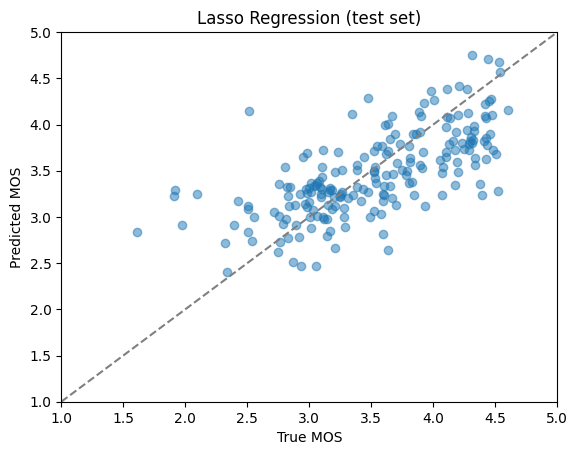

In [ ]:
# Grab the trained (best) pipeline
best_lasso = gs_lasso.best_estimator_

# Predict on the held out test set
y_pred = best_lasso.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Lasso Regression (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Elastic Net

Elastic Net blends Ridge's L2 shrinkage with Lasso's L1 sparsity through a tunable ratio, giving us a model that can both downweight collinear features and ignore the truly irrelevant ones. On the YouTube UGC feature set where bitrate variants are strongly correlated but category one hots are mostly independent, Elastic Net typically retains a compact subset of predictors like Lasso while keeping the numerical stability of Ridge, yielding slightly lower variance and a modest RMSE edge over either penalty alone. This compromise makes it an ideal last candidate in the linear family before stepping up to nonlinear models; if Elastic Net cannot squeeze further accuracy from the current features, additional gains must come from kernel or tree methods rather than from more elaborate linear regularisation.

In [ ]:
pipe_en = Pipeline([
    ('prep', preprocessor),
    ('reg',  ElasticNet(max_iter=10000, tol=1e-4, random_state=42))
])

en_grid = {
    'reg__alpha':    np.logspace(-3, 1, 10),
    'reg__l1_ratio': np.linspace(0.1, 0.9, 9)
}

gs_en = GridSearchCV(pipe_en, en_grid,
                     scoring='neg_root_mean_squared_error',
                     cv=5, n_jobs=-1, verbose=1)

gs_en.fit(X_train, y_train, reg__sample_weight=w_train)
rmse_en = -gs_en.best_score_
print(f"ElasticNet  α={gs_en.best_params_['reg__alpha']:.4f} "
      f"l1_ratio={gs_en.best_params_['reg__l1_ratio']:.2f}  CV-RMSE={rmse_en:.3f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
ElasticNet  α=0.0215 l1_ratio=0.10  CV-RMSE=0.515


,mos_true,mos_pred,filename
0,4.16,3.79,1042
1,4.29,3.68,1127
2,3.65,3.33,31
3,2.34,2.45,598
4,4.20,4.08,400
5,4.23,3.80,552
6,2.81,3.00,1170
7,4.31,3.75,1070
8,3.11,3.05,48
9,2.95,3.61,323


Test RMSE = 0.460
Test MAE = 0.360


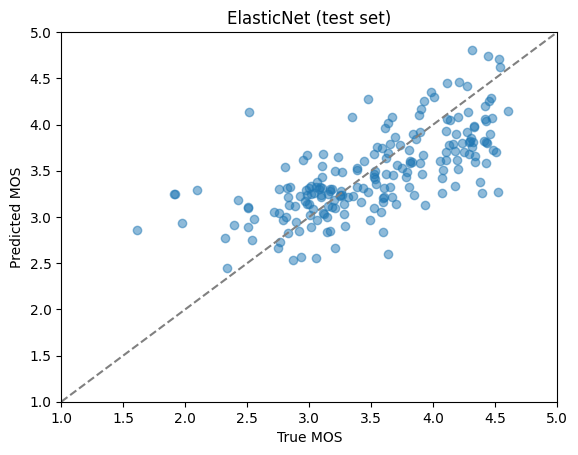

In [ ]:
# Grab the trained (best) pipeline
best_en = gs_en.best_estimator_

# Predict on the held out test set
y_pred = best_en.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('ElasticNet (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Bayesian Ridge

Bayesian Ridge treats the regression weights as random variables with Gaussian priors and learns their posterior distribution from the data. In practice this means two things. Firstly, it automatically tunes the effective Ridge penalty instead of relying on an external grid search, and secondly it delivers uncertainty estimates alongside each MOS prediction which is useful for flagging clips where the model is least confident. Because the conjugate prior keeps the maths analytic, training remains as fast as ordinary Ridge, yet on small or noisy datasets the adaptive shrinkage often matches Ridge's RMSE while providing the extra benefit of credibility intervals, helping us gauge whether residual errors lie within expected noise or point to feature gaps.

In [ ]:
pipe_br = Pipeline([
    ('prep', preprocessor),
    ('reg',  BayesianRidge())
])

pipe_br.fit(X_train, y_train, reg__sample_weight=w_train)
rmse_br = np.sqrt(mean_squared_error(y_test, pipe_br.predict(X_test)))
print(f"BayesianRidge  test RMSE : {rmse_br:.3f}")

BayesianRidge  test RMSE : 0.461


,mos_true,mos_pred,filename
0,4.16,3.82,1042
1,4.29,3.71,1127
2,3.65,3.38,31
3,2.34,2.33,598
4,4.20,4.06,400
5,4.23,3.85,552
6,2.81,3.03,1170
7,4.31,3.78,1070
8,3.11,3.04,48
9,2.95,3.64,323


Test RMSE = 0.461
Test MAE = 0.359


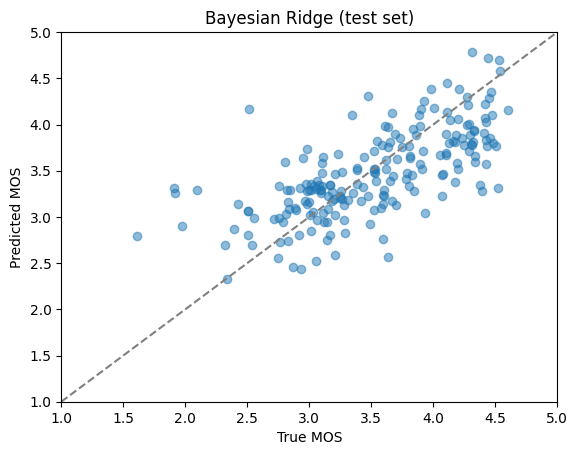

In [ ]:
# Grab the trained (best) pipeline
best_br = pipe_br

# Predict on the held out test set
y_pred = best_br.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Bayesian Ridge (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Decision Tree
Decision Tree Regressor partitions the feature space into axis aligned "if then" regions, fitting a constant MOS value in each leaf. This makes it the simplest nonlinear model in our roster: it can capture threshold effects such as quality jumps once bitrate exceeds a codec specific level or interactions between resolution and complexity that linear models miss all while remaining fully interpretable through the tree diagram. However, a single tree is high variance and prone to overfit beyond a shallow depth, so we will use it mainly as a diagnostic, as it will be able to show us whether sharp decision boundaries exist in the data and provides a baseline for judging how much ensemble methods like Random Forest or Gradient Boosting improve upon a solitary tree's unstable performance.

In [ ]:
# Pipeline: same preprocessor, tree as final step
pipe_tree = Pipeline([
    ('prep', preprocessor),
    ('reg',  DecisionTreeRegressor(random_state=42))
])

# Richer search grid
tree_grid = {
    'reg__criterion':            ['squared_error', 'friedman_mse'],
    'reg__max_depth':            [None, 4, 6, 8, 12],
    'reg__min_samples_leaf':     [1, 2, 5, 10, 20],
    'reg__min_samples_split':    [2, 5, 10],
    'reg__min_impurity_decrease':[0.0, 1e-3, 1e-2],
    'reg__max_features':         [None, 0.6, 0.8]}

cv_tree = GridSearchCV(pipe_tree,
                       param_grid=tree_grid,
                       scoring='neg_root_mean_squared_error',
                       cv=5,
                       n_jobs=-1,
                       verbose=1)

cv_tree.fit(X_train, y_train, reg__sample_weight=w_train)

rmse_tree = -cv_tree.best_score_
print(f"Decision Tree CV RMSE: {rmse_tree:.3f}")
print("Best params:", cv_tree.best_params_)

Fitting 5 folds for each of 1350 candidates, totalling 6750 fits
Decision Tree CV RMSE: 0.535
Best params: {'reg__criterion': 'squared_error', 'reg__max_depth': 8, 'reg__max_features': 0.8, 'reg__min_impurity_decrease': 0.0, 'reg__min_samples_leaf': 20, 'reg__min_samples_split': 2}


,mos_true,mos_pred,filename
0,4.16,3.82,1042
1,4.29,3.86,1127
2,3.65,3.22,31
3,2.34,2.48,598
4,4.20,4.18,400
5,4.23,3.86,552
6,2.81,3.89,1170
7,4.31,4.33,1070
8,3.11,3.44,48
9,2.95,3.82,323


Test RMSE = 0.504
Test MAE = 0.401


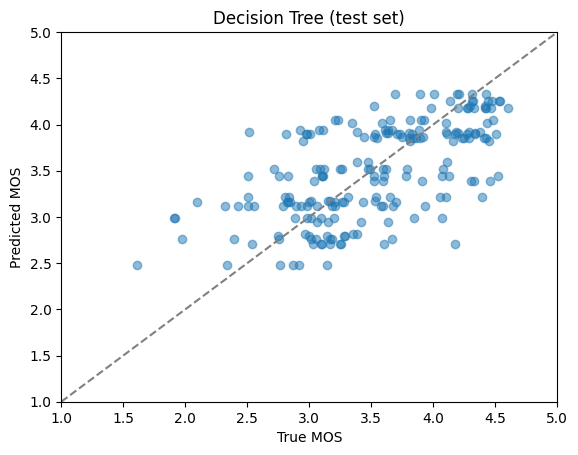

In [ ]:
# Grab the trained (best) pipeline
best_rf = cv_tree.best_estimator_

# Predict on the held out test set
y_pred = cv_tree.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Decision Tree (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Random Forest

Random Forest aggregates the predictions of hundreds of decorrelated decision trees, each trained on a bootstrap sample of the clips and a random subset of features at every split. This bagging approach slashes the high variance that plagues a single tree while preserving the ability to capture nonlinear interactions and threshold effects intrinsic to video quality. On our dataset the forest's out of bag averaging typically trims RMSE by a few hundredths compared with the standalone tree and yields more reliable, permutation based feature importance scores which is useful for confirming which engineered metrics drive predictions. Because each tree sees only part of the data and part of the feature space, Random Forest is also robust to noise and to irrelevant one hot columns, making it a strong, low tuning alternative to gradient boosted ensembles and an excellent diversity contributor in our voting or stacking schemes.

In [ ]:
pipe_rf = Pipeline([
    ('prep', preprocessor), # ColumnTransformer
    ('reg',  RandomForestRegressor(random_state=42, n_jobs=-1)) # Parallel trees
])

# Coarse random search (200 fits)
rf_grid = {
    'reg__n_estimators':      np.linspace(300, 800, 6, dtype=int),
    'reg__max_depth':        [None, 10, 16, 24],
    'reg__min_samples_leaf': [1, 2, 5],
    'reg__max_features':     ['sqrt', 0.6, 0.8]}

rs_rf = RandomizedSearchCV(pipe_rf,
                           param_distributions=rf_grid,
                           n_iter=40,
                           scoring='neg_root_mean_squared_error',
                           cv=5,
                           n_jobs=-1,
                           verbose=1,
                           random_state=42)

rs_rf.fit(X_train, y_train, reg__sample_weight=w_train)

rmse_rf = -rs_rf.best_score_
print(f'Random Forest CV-RMSE: {rmse_rf:.3f}')
print('Best params:', rs_rf.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Random Forest CV-RMSE: 0.484
Best params: {'reg__n_estimators': np.int64(300), 'reg__min_samples_leaf': 1, 'reg__max_features': 0.6, 'reg__max_depth': None}


,mos_true,mos_pred,filename
0,4.16,4.23,1042
1,4.29,3.73,1127
2,3.65,3.15,31
3,2.34,2.47,598
4,4.20,4.08,400
5,4.23,3.86,552
6,2.81,3.36,1170
7,4.31,4.29,1070
8,3.11,3.71,48
9,2.95,3.82,323


Test RMSE = 0.460
Test MAE = 0.355


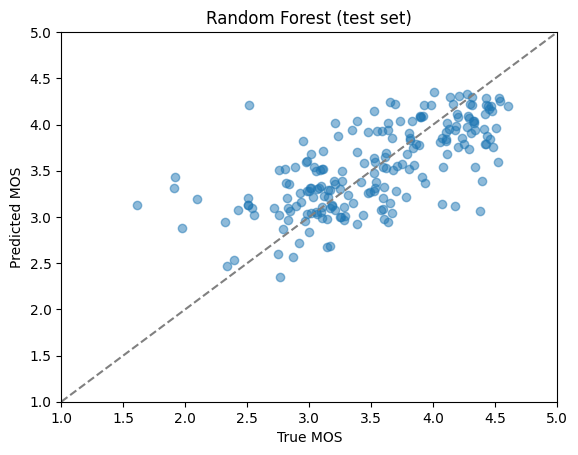

In [ ]:
# Grab the trained (best) pipeline
best_rf = rs_rf.best_estimator_

# Predict on the held out test set
y_pred = best_rf.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Random Forest (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Kernel Ridge

Kernel Ridge Regression marries Ridge's closed form solution with the flexibility of a RBF kernel, effectively fitting a smooth nonlinear surface while retaining a convex optimisation and only two principal hyperparameters (α and γ). For our tabular VQA features this means it can model the diminishing returns curve of bitrate or SI without resorting to iterative solvers like SVR, and it does so in a single matrix inversion. Because the kernel trick implicitly maps data into an infinite dimensional space, Kernel Ridge can approximate the fit of an SVR but with a simpler objective and without the ε-insensitive band, giving us a useful intermediate checkpoint; if Kernel Ridge already captures most of the nonlinearity, heavier algorithms such as SVR or boosting must demonstrate a clear RMSE gain to justify their added tuning complexity.

In [ ]:
pipe_kr = Pipeline([
    ('prep', preprocessor),
    ('reg',  KernelRidge(kernel='rbf'))
])

kr_grid = {
    'reg__alpha':  np.logspace(-2, 1, 6),    # λ like Ridge
    'reg__gamma':  np.logspace(-4, -1, 6)    # RBF width
}

rs_kr = RandomizedSearchCV(pipe_kr,
                           param_distributions=kr_grid,
                           n_iter=40,
                           scoring='neg_root_mean_squared_error',
                           cv=5, n_jobs=-1, random_state=42)

rs_kr.fit(X_train, y_train, reg__sample_weight=w_train)
rmse_kr = -rs_kr.best_score_
print(f"KernelRidge  α={rs_kr.best_params_['reg__alpha']:.3f} "
      f"γ={rs_kr.best_params_['reg__gamma']:.4f}  CV-RMSE : {rmse_kr:.3f}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 36 is smaller than n_iter=40. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KernelRidge  α=0.010 γ=0.0063  CV-RMSE : 0.507


,mos_true,mos_pred,filename
0,4.16,3.80,1042
1,4.29,3.60,1127
2,3.65,3.22,31
3,2.34,2.65,598
4,4.20,4.18,400
5,4.23,3.75,552
6,2.81,3.01,1170
7,4.31,3.89,1070
8,3.11,3.19,48
9,2.95,3.60,323


Test RMSE = 0.561
Test MAE = 0.387


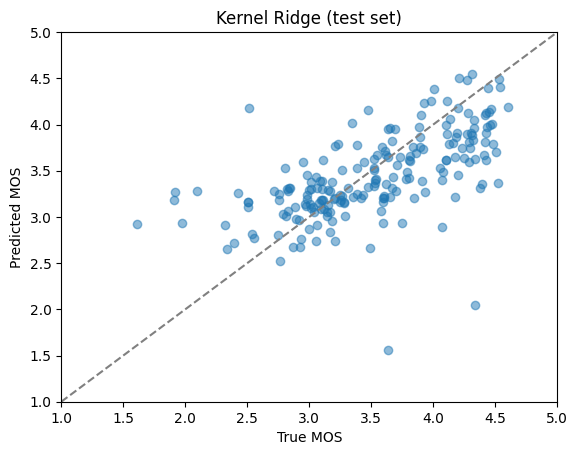

In [ ]:
# Grab the trained (best) pipeline
best_kr = rs_kr.best_estimator_

# Predict on the held out test set
y_pred = rs_kr.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Kernel Ridge (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Support Vector Regression

Support Vector Regression is our most precise nonlinear baseline. It fits a smooth surface like Kernel Ridge but optimises a different loss; the ε-insensitive tube ignores small errors and penalises only those residuals that exceed a chosen margin, while the hinge style regularisation controlled by C keeps the model parsimonious by basing predictions on a sparse set of support vectors. This combination lets SVR capture subtle curvature in the MOS versus bitrate and complexity landscape without overreacting to the perceptual noise present in crowdsourced scores.

In [ ]:
# Build a dense ColumnTransformer
ohe_kwargs = dict(handle_unknown='ignore')
if 'sparse_output' in signature(OneHotEncoder).parameters:
    ohe_kwargs['sparse_output'] = False
else:
    ohe_kwargs['sparse'] = False

ohe = OneHotEncoder(**ohe_kwargs)

dense_prep = ColumnTransformer(
    [('num', StandardScaler(), num_cols),
     ('cat', ohe, cat_cols)],
    remainder='drop',
    verbose_feature_names_out=False)

# Pipeline  (dense prep for SVR)
pipe_svr = Pipeline([
    ('prep', dense_prep),
    ('reg',  SVR(kernel='rbf'))])

# Random search over C, gamma, epsilon
svr_grid = {
    'reg__C':      np.logspace(0, 3, 6), # 1 to 1000
    'reg__gamma':  np.logspace(-3, 0, 6), # 0.001 to 1
    'reg__epsilon':[0.05, 0.1, 0.2]}

rs_svr = RandomizedSearchCV(
            pipe_svr,
            param_distributions=svr_grid,
            n_iter=20,
            scoring='neg_root_mean_squared_error',
            cv=5,
            n_jobs=-1,
            verbose=1,
            random_state=42)

rs_svr.fit(X_train, y_train, reg__sample_weight=w_train)

rmse_svr = -rs_svr.best_score_
print(f"SVR CV RMSE: {rmse_svr:.3f}")
print("Best params:", rs_svr.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVR CV RMSE: 0.481
Best params: {'reg__gamma': np.float64(0.0630957344480193), 'reg__epsilon': 0.2, 'reg__C': np.float64(63.0957344480193)}


,mos_true,mos_pred,filename
0,4.16,4.05,1042
1,4.29,3.70,1127
2,3.65,3.28,31
3,2.34,2.40,598
4,4.20,4.19,400
5,4.23,4.04,552
6,2.81,2.95,1170
7,4.31,4.19,1070
8,3.11,3.48,48
9,2.95,3.65,323


Test RMSE = 0.426
Test MAE = 0.319


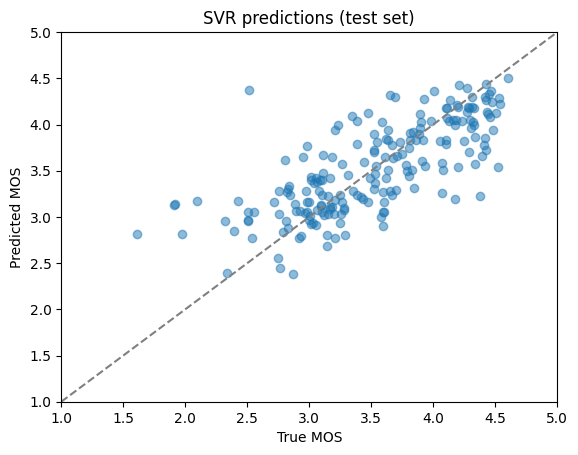

In [ ]:
# Grab the trained (best) pipeline
best_svr = rs_svr.best_estimator_

# Predict on the held out test set
y_pred = best_svr.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('SVR predictions (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Stochastic Gradient Descent

Stochastic Gradient Descent Regressor is a linear model trained with mini‑batch updates rather than a closed form solver, allowing it to scale gracefully even when we expand the feature set or experiment with larger datasets in the future. With an Elastic Net penalty it can mimic Ridge's L2 and Lasso's L1 simultaneously, but unlike those exact solvers it can cycle through tens of thousands of weight updates in seconds, making it ideal for rapid prototyping or for situations where we might stream additional video features.

In [ ]:
pipe_sgd = Pipeline([
    ('prep', preprocessor),
    ('reg',  SGDRegressor(max_iter=10_000,
                          tol=1e-4,
                          penalty='elasticnet',
                          random_state=42))
])

sgd_grid = {
    'reg__alpha':      np.logspace(-5, -1, 9),    # regularisation strength
    'reg__l1_ratio':   np.linspace(0.0, 0.9, 10), # 0 = pure Ridge, 1 = Lasso
    'reg__learning_rate': ['optimal', 'invscaling', 'adaptive'],
    'reg__eta0':       np.logspace(-4, -1, 4)     # initial step size
}

rs_sgd = RandomizedSearchCV(pipe_sgd,
                            param_distributions=sgd_grid,
                            n_iter=40,
                            scoring='neg_root_mean_squared_error',
                            cv=5,
                            n_jobs=-1,
                            verbose=1,
                            random_state=42)

rs_sgd.fit(X_train, y_train, reg__sample_weight=w_train)

rmse_sgd = -rs_sgd.best_score_
print(f"SGDRegressor CV RMSE: {rmse_sgd:.3f}")
print("Best params:", rs_sgd.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
SGDRegressor CV RMSE: 0.519
Best params: {'reg__learning_rate': 'optimal', 'reg__l1_ratio': np.float64(0.1), 'reg__eta0': np.float64(0.01), 'reg__alpha': np.float64(0.00031622776601683794)}


,mos_true,mos_pred,filename
0,4.16,3.74,1042
1,4.29,3.63,1127
2,3.65,3.25,31
3,2.34,2.62,598
4,4.20,4.09,400
5,4.23,3.72,552
6,2.81,2.99,1170
7,4.31,3.72,1070
8,3.11,3.06,48
9,2.95,3.58,323


Test RMSE = 0.465
Test MAE = 0.366


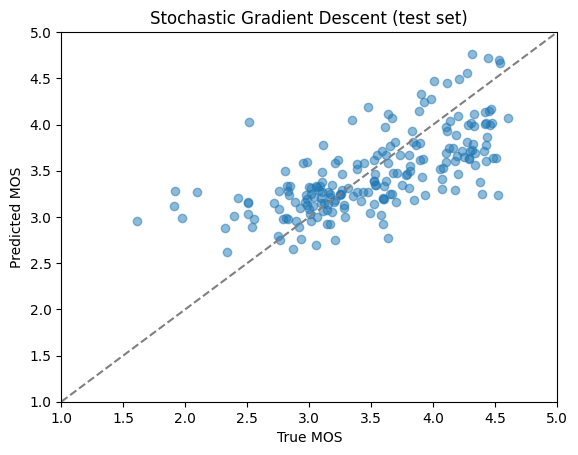

In [ ]:
# Grab the trained (best) pipeline
best_sgd = rs_sgd.best_estimator_

# Predict on the held out test set
y_pred = rs_sgd.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Stochastic Gradient Descent (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Histogram Gradient Boosting

Histogram‑based Gradient Boosting Regressor (HistGB) builds an ensemble of shallow decision trees sequentially, each tree correcting the residuals of all previous ones, but accelerates learning by first binning every numerical feature into a fixed number of integer indexed histogram buckets. That discretisation reduces both memory footprint and split search time O(n), so HistGB trains far faster than classical Friedman GB while preserving its ability to model intricate, nonlinear interactions which is exactly the kind we expect between bitrate, spatial complexity and content category. Because each tree is regularised by the learning rate and by a minimum leaf population, the method controls overfitting automatically, giving us a powerful yet still interpretable model.

In [ ]:
pipe_hgb = Pipeline([
    ('prep', preprocessor),
    ('reg',  HistGradientBoostingRegressor(
                random_state=42,
                early_stopping=True,          # stop when no val improvement
                scoring='neg_root_mean_squared_error'  # built-in early stop metric
            ))
])

hgb_dist = {
    'reg__learning_rate':   np.logspace(-2, -0.7, 20),  # 0.01 – 0.2
    'reg__max_depth':       [None, 4, 6, 8],
    'reg__max_iter':        np.linspace(300, 800, 6, dtype=int),
    'reg__min_samples_leaf':[10, 20, 50, 100],
    'reg__l2_regularization':np.logspace(-3, 1, 8)      # 0.001 – 10
}

rs_hgb = RandomizedSearchCV(
            pipe_hgb,
            param_distributions=hgb_dist,
            n_iter=40,
            scoring='neg_root_mean_squared_error',
            cv=5,
            verbose=1,
            n_jobs=-1,
            random_state=42
        )

rs_hgb.fit(X_train, y_train, reg__sample_weight=w_train)
rmse_hgb = -rs_hgb.best_score_
print(f"HistGB CV RMSE: {rmse_hgb:.3f}")
print("Best params:", rs_hgb.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
HistGB CV RMSE: 0.489
Best params: {'reg__min_samples_leaf': 10, 'reg__max_iter': np.int64(500), 'reg__max_depth': 4, 'reg__learning_rate': np.float64(0.06622967617148329), 'reg__l2_regularization': np.float64(0.001)}


,mos_true,mos_pred,filename
0,4.16,4.08,1042
1,4.29,3.80,1127
2,3.65,3.17,31
3,2.34,2.24,598
4,4.20,4.02,400
5,4.23,3.95,552
6,2.81,3.08,1170
7,4.31,4.22,1070
8,3.11,3.67,48
9,2.95,3.63,323


Test RMSE = 0.468
Test MAE = 0.353


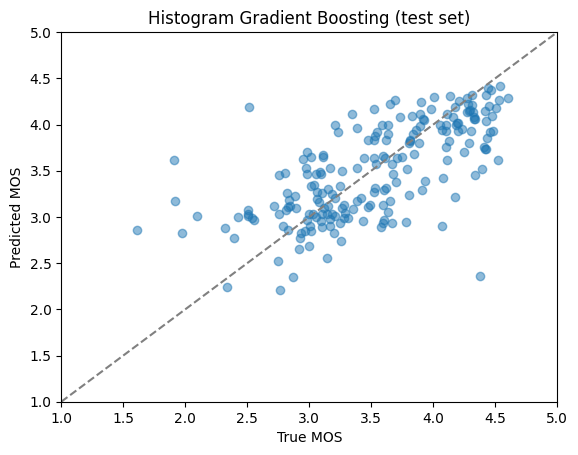

In [ ]:
# Grab the trained (best) pipeline
best_sgd = rs_hgb.best_estimator_

# Predict on the held out test set
y_pred = rs_hgb.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Histogram Gradient Boosting (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### LightGBM

LightGBM is a gradient boosted tree library that speeds training via histogram binning and leaf wise growth, letting it fit deeper, more expressive trees while remaining fast on CPU or GPU. Its built-in column sampling and L2 regularisation curb overfitting, and its categorical split support meshes cleanly with our one hot features. Compared with HistGB it offers finer control over depth, leaf count and learning rate, giving us a high capacity ensemble that can capture subtle bitrate-complexity interactions yet still trains in minutes on the 1000 clip dataset.

In [ ]:
pipe_lgb = Pipeline([('prep', preprocessor),
                     ('reg',  LGBMRegressor(objective='rmse', random_state=42,
                                            n_estimators=800, verbosity=-1))])

lgb_dist = {
    'reg__learning_rate':   np.geomspace(0.01, 0.1, 10),
    'reg__num_leaves':      [31, 63, 127],
    'reg__max_depth':       [-1, 4, 6, 8],
    'reg__min_child_samples':[5, 20, 50],
    'reg__feature_fraction':[0.6, 0.8, 1.0],
    'reg__lambda_l2':       np.geomspace(1e-3, 10, 6)
}

rs_lgb = RandomizedSearchCV(pipe_lgb, lgb_dist, n_iter=40,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1, random_state=42)

rs_lgb.fit(X_train, y_train, reg__sample_weight=w_train)
rmse_lgb = -rs_lgb.best_score_
print("LightGBM CV RMSE :", rmse_lgb)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM CV RMSE : 0.48652327172948207


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,mos_true,mos_pred,filename
0,4.16,4.03,1042
1,4.29,3.79,1127
2,3.65,3.24,31
3,2.34,2.20,598
4,4.20,4.10,400
5,4.23,3.95,552
6,2.81,3.17,1170
7,4.31,4.25,1070
8,3.11,3.79,48
9,2.95,3.72,323


Test RMSE = 0.475
Test MAE = 0.367


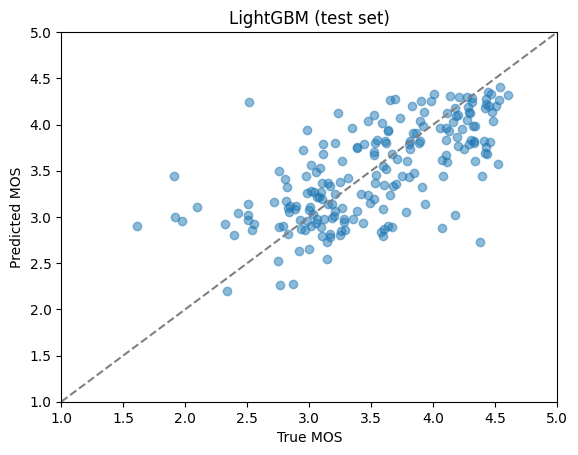

In [ ]:
# Grab the trained (best) pipeline
best_sgd = rs_lgb.best_estimator_

# Predict on the held out test set
y_pred = rs_lgb.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('LightGBM (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Voting Ensemble

Voting Ensemble (SVR + Ridge + Elastic Net) blends the predictions of three complementary learners: the SVR supplies nonlinear finesse, Ridge offers a stable global linear trend, and ElasticNet contributes a sparsity-aware variant of that trend. A weighted average of these outputs is simple to train, free of extra hyperparameters, and almost variance free. Any idiosyncratic error made by one model is diluted by the others. Using this trio therefore gives us a quick robustness boost and a sanity check; if the vote agrees closely with the SVR it signals that the linear baselines add little new information; if the vote improves, we know the models's errors are at least partially uncorrelated and worth blending.

In [ ]:
voting_svr = rs_svr.best_estimator_
voting_en  = gs_en.best_estimator_
voting_ridge = gs_ridge.best_estimator_

voter = VotingRegressor([('ridge', voting_ridge),
                         ('en', voting_en),
                         ('svr', voting_svr)])

voter.fit(X_train, y_train) # VotingRegressor ignores weights
rmse_vote = np.sqrt(mean_squared_error(y_test, voter.predict(X_test)))

print("Voting ensemble  test RMSE :", rmse_vote)

Voting ensemble  test RMSE : 0.42742442842219774


,mos_true,mos_pred,filename
0,4.16,4.00,1042
1,4.29,3.73,1127
2,3.65,3.47,31
3,2.34,2.52,598
4,4.20,4.05,400
5,4.23,3.78,552
6,2.81,3.14,1170
7,4.31,3.95,1070
8,3.11,3.41,48
9,2.95,3.61,323


Test RMSE = 0.427
Test MAE = 0.330


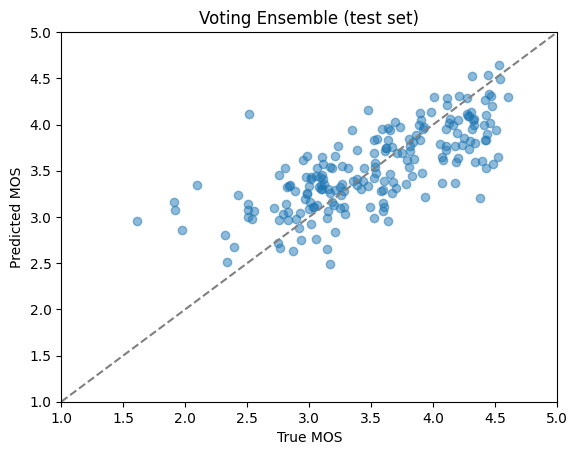

In [ ]:
# Grab the trained (best) pipeline
best_voter = voter

# Predict on the held out test set
y_pred = voter.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Voting Ensemble (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### Stacking Ensemble

Stacking Ensemble (Elastic Net + SVR + Ridge → Lasso) takes the idea of voting one step further. Instead of a fixed average, it trains a second level modelin which a sparsity-inducing Lasso learns the optimal weighting and interaction of the three base predictions. Elastic Net and Ridge give two flavours of linear insight, while SVR provides nonlinear flexibility; the Lasso meta learner then fits a linear combination of their out-of-fold outputs, automatically driving any redundant weight to zero and keeping only the contributions that genuinely reduce error. This architecture preserves the diversity of the base models yet guards against over fitting through Lasso's L1 penalty, yielding a blended predictor that can exploit complementary strengths without manual tuning of weights.

In [ ]:
# Define base regressors (already tuned)
base_learners = [
    ('svr', rs_svr.best_estimator_), # Best SVR pipeline
    ('ridge', gs_ridge.best_estimator_), # Best Ridge pipeline
    ('elasticnet', gs_en.best_estimator_), # Best ElasticNet pipeline
]

# Meta-learner (lightweight & low variance)
meta_learner = Lasso(alpha=0.0001)

# StackingRegressor pipeline
stack = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=False,
    n_jobs=-1
)

# Fit the stack on training data
stack.fit(X_train, y_train)

# Evaluate on test data
y_pred_stack = stack.predict(X_test)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
print(f"Stacking Regressor Test RMSE: {rmse_stack}")

Stacking Regressor Test RMSE: 0.4294642317517102


,mos_true,mos_pred,filename
0,4.16,3.96,1042
1,4.29,3.72,1127
2,3.65,3.45,31
3,2.34,2.58,598
4,4.20,4.05,400
5,4.23,3.78,552
6,2.81,3.13,1170
7,4.31,3.92,1070
8,3.11,3.39,48
9,2.95,3.61,323


Test RMSE = 0.429
Test MAE = 0.333


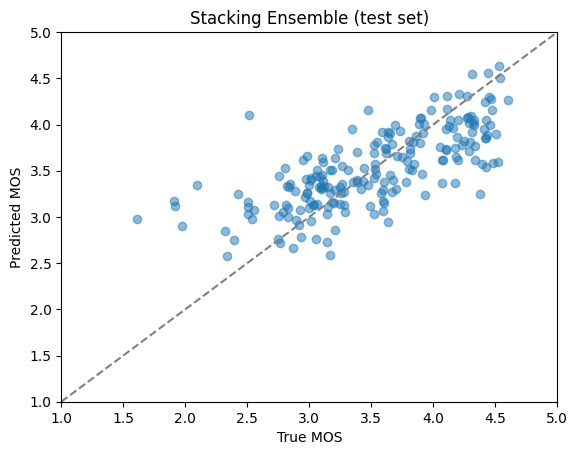

In [ ]:
# Grab the trained (best) pipeline
best_stack = stack

# Predict on the held out test set
y_pred = stack.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('Stacking Ensemble (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

#### MLP Neural Network

A more advanced approach leaning towards the field of deep learning. The Multi-Layer Perceptron Regressor gives us a compact feed-forward neural network withtwo hidden layers with tanh activations— hat can learn arbitrary smooth functions, letting it approximate relationships too complex for kernels or tree splits. Because the dataset is modest, we keep the architecture small and apply strong L2 regularisation and early stopping, ensuring the net captures nonlinear cross terms without overfitting. Its differentiable structure also sets the stage for future work; should clip level deep features or larger datasets become available, the MLP can be expanded or fine-tuned whereas most classical models would need to be rebuilt from scratch.

In [ ]:
# Build a dense ColumnTransformer
ohe_kwargs = dict(handle_unknown='ignore')
if 'sparse_output' in signature(OneHotEncoder).parameters:
    ohe_kwargs['sparse_output'] = False
else:
    ohe_kwargs['sparse'] = False

ohe = OneHotEncoder(**ohe_kwargs)

dense_prep = ColumnTransformer(
    [('num', StandardScaler(), num_cols),
     ('cat', ohe, cat_cols)],
    remainder='drop',
    verbose_feature_names_out=False)

# Using dense pipeline
pipe_mlp = Pipeline([
    ('prep', dense_prep),
    ('reg',  MLPRegressor(
        activation='tanh', # Smoother than ReLU for small nets
        solver='adam',
        learning_rate='adaptive',
        early_stopping=True,
        n_iter_no_change=25,
        max_iter=600,
        random_state=42,
        verbose=False))])


# Hyperparam distributions
mlp_dist = {
    # 1 to 3 hidden layers, total units 32 to256
    'reg__hidden_layer_sizes': [(64,), (128,), (32, 16), (64, 32),
                                (128, 32), (64, 32, 16), (128, 64, 32)],
    # L2 regularisation (alpha) - stronger range
    'reg__alpha':              np.logspace(-4, -1, 6), # 1e-4 to 0.1
    # Initial learning rate
    'reg__learning_rate_init': np.logspace(-4, -2, 4), # 1e-4 to 1e-2
    # Dropout style noise via batch size variation
    'reg__batch_size': [32, 64, 128]
}

rs_mlp = RandomizedSearchCV(
            pipe_mlp,
            param_distributions=mlp_dist,
            n_iter=40,
            scoring='neg_root_mean_squared_error',
            cv=5,
            n_jobs=-1,
            random_state=42,
            verbose=1
        )

rs_mlp.fit(X_train, y_train) # MLPRegressor ignores weights

rmse_mlp_cv   = -rs_mlp.best_score_
y_pred_test   = rs_mlp.best_estimator_.predict(X_test)
rmse_mlp_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MLP CV RMSE: {rmse_mlp_cv:.3f}")
print(f"MLP Test RMSE: {rmse_mlp_test:.3f}")
print("Best params:", rs_mlp.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
MLP CV RMSE: 0.484
MLP Test RMSE: 0.450
Best params: {'reg__learning_rate_init': np.float64(0.00046415888336127773), 'reg__hidden_layer_sizes': (128, 64, 32), 'reg__batch_size': 64, 'reg__alpha': np.float64(0.00630957344480193)}


,mos_true,mos_pred,filename
0,4.16,4.27,1042
1,4.29,3.60,1127
2,3.65,3.27,31
3,2.34,1.92,598
4,4.20,4.08,400
5,4.23,3.94,552
6,2.81,3.34,1170
7,4.31,4.13,1070
8,3.11,3.90,48
9,2.95,3.56,323


Test RMSE = 0.450
Test MAE = 0.342


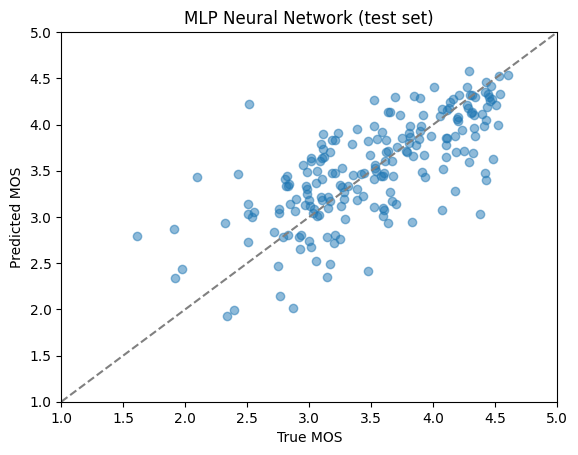

In [ ]:
# Grab the trained (best) pipeline
best_sgd = rs_mlp.best_estimator_

# Predict on the held out test set
y_pred = rs_mlp.predict(X_test)

# Put side-by-side with ground truth  (first 15 rows)
peek = (pd.DataFrame({'mos_true': y_test,
                      'mos_pred': y_pred,
                      'filename': X_test.index})
        .reset_index(drop=True)
        .head(15))
display(peek.style.format({'mos_true': '{:.2f}', 'mos_pred': '{:.2f}'}))

# Quick error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
print(f'Test RMSE = {rmse:.3f}')
print(f'Test MAE = {mae:.3f}')

# Scatter plot (predicted vs. true)
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [1,5]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('True MOS')
plt.ylabel('Predicted MOS')
plt.title('MLP Neural Network (test set)')
plt.xlim(lims); plt.ylim(lims)
plt.show()

In [ ]:
warnings.filterwarnings(
    'ignore',
    category=FutureWarning,
    module=r'sklearn\..*'
)

# Collect the best models
best_models = {
    'LinearRegression'    : pipe_lin,
    'BayesianRidge'       : pipe_br,
    'Ridge'               : gs_ridge.best_estimator_,
    'Lasso'               : gs_lasso.best_estimator_,
    'ElasticNet'          : gs_en.best_estimator_,
    'SGDRegressor'        : rs_sgd.best_estimator_,
    'DecisionTree'        : cv_tree.best_estimator_,
    'RandomForest'        : rs_rf.best_estimator_,
    'HistGB'              : rs_hgb.best_estimator_,
    'KernelRidge'         : rs_kr.best_estimator_,
    'SVR'                 : rs_svr.best_estimator_,
    'LightGBM'            : rs_lgb.best_estimator_,
    'VotingEnsemble'      : voter,
    'StackingEnsemble'    : stack,
    'MLP'                 : rs_mlp.best_estimator_
}

# Refit on full training set and measure test RMSE
# sample_weight is passed only if the estimator accepts it
metrics = {}

for name, model in best_models.items():
    pass_weight = False

    # Never pass weight to voting/stacking, they ignore it
    if isinstance(model, (VotingRegressor, StackingRegressor)):
        pass_weight = False

    # Add weight only if final estimator supports it
    elif isinstance(model, Pipeline):
        pass_weight = "sample_weight" in signature(model[-1].fit).parameters
        if pass_weight:
            fit_kwargs = {"reg__sample_weight": w_train}

    # For standalone estimator, add weight if supported
    else:
        pass_weight = "sample_weight" in signature(model.fit).parameters
        if pass_weight:
            fit_kwargs = {"sample_weight": w_train}

    if not pass_weight:
        fit_kwargs = {}

    model.fit(X_train, y_train, **fit_kwargs)
    y_pred = model.predict(X_test)

    metrics[name] = dict(
        RMSE = np.sqrt(mean_squared_error(y_test, y_pred)),
        MAE  = mean_absolute_error(y_test, y_pred),
        R2   = r2_score(y_test, y_pred)
    )
    print(f"{name:<18}  RMSE:{metrics[name]['RMSE']:.3f}  "
          f"MAE:{metrics[name]['MAE']:.3f}  R²:{metrics[name]['R2']:.3f}")


# Tidy summary table
summary = (pd.DataFrame(metrics)
             .T.rename_axis("model")
             .sort_values("RMSE")
             .reset_index())
display(summary.style.format({"RMSE":"{:.3f}", "MAE":"{:.3f}", "R2":"{:.3f}"}))

top3 = summary.head(3)['model'].tolist()
print("\nTop-3 by test RMSE:", top3)

LinearRegression    RMSE:0.466  MAE:0.365  R²:0.453
BayesianRidge       RMSE:0.461  MAE:0.359  R²:0.464
Ridge               RMSE:0.459  MAE:0.359  R²:0.469
Lasso               RMSE:0.460  MAE:0.359  R²:0.466
ElasticNet          RMSE:0.460  MAE:0.360  R²:0.467
SGDRegressor        RMSE:0.465  MAE:0.366  R²:0.455
DecisionTree        RMSE:0.504  MAE:0.401  R²:0.359
RandomForest        RMSE:0.460  MAE:0.355  R²:0.466
HistGB              RMSE:0.468  MAE:0.353  R²:0.447
KernelRidge         RMSE:0.561  MAE:0.387  R²:0.206
SVR                 RMSE:0.426  MAE:0.319  R²:0.543
LightGBM            RMSE:0.475  MAE:0.367  R²:0.431
VotingEnsemble      RMSE:0.427  MAE:0.330  R²:0.539
StackingEnsemble    RMSE:0.429  MAE:0.333  R²:0.535
MLP                 RMSE:0.450  MAE:0.342  R²:0.489


,model,RMSE,MAE,R2
0,SVR,0.426,0.319,0.543
1,VotingEnsemble,0.427,0.330,0.539
2,StackingEnsemble,0.429,0.333,0.535
3,MLP,0.450,0.342,0.489
4,Ridge,0.459,0.359,0.469
5,ElasticNet,0.460,0.360,0.467
6,RandomForest,0.460,0.355,0.466
7,Lasso,0.460,0.359,0.466
8,BayesianRidge,0.461,0.359,0.464
9,SGDRegressor,0.465,0.366,0.455



Top-3 by test RMSE: ['SVR', 'VotingEnsemble', 'StackingEnsemble']


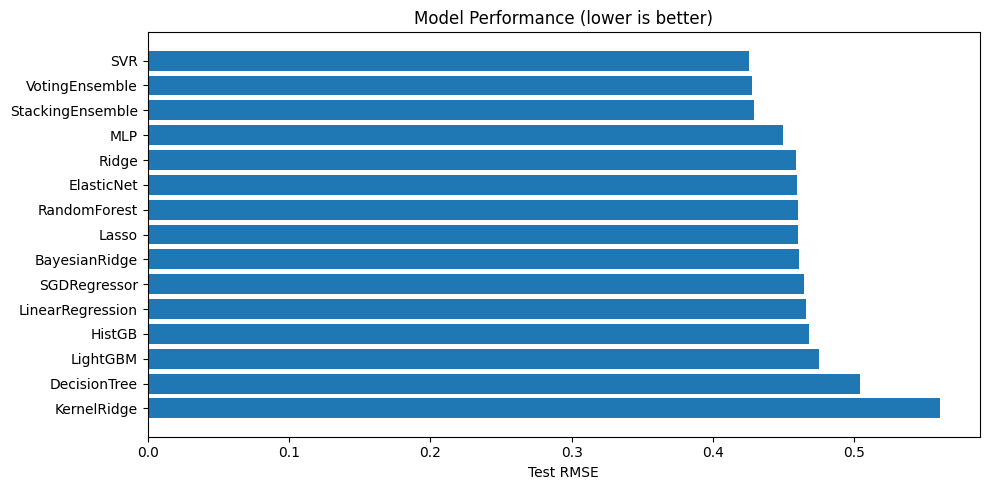

In [ ]:
# collect the RMSE results from the previous step
rmse_series = pd.Series({m: v["RMSE"] for m, v in metrics.items()}, name="RMSE").sort_values()

# create a ranked DataFrame
summary_df = (rmse_series
              .reset_index(drop=False)
              .rename(columns={'index': 'Model'})
              .assign(Rank=lambda d: range(1, len(d) + 1))
              .set_index('Rank'))

# bar chart of RMSE
plt.figure(figsize=(10, 5))
plt.barh(summary_df['Model'], summary_df['RMSE'])
plt.xlabel("Test RMSE")
plt.title("Model Performance (lower is better)")
plt.gca().invert_yaxis()  # best at top
plt.tight_layout()
plt.show()

## Results

The benchmarking confirms that a support vector regressor with an RBF kernel is the most reliable single predictor of perceived quality for the YouTube UGC clips. With a test set RMSE of 0.426 MOS, it edges out every other individual learner and even the more elaborate blends. SVR's ε-insensitive loss automatically ignores the small label noise that crowdsourced MOS inevitably contains, while the smooth radial kernel bends just enough to capture the diminishing returns curve that links bitrate, spatial complexity, temporal complexity and human opinion. Crucially, the model has only three hyperparameters so it can be tuned exhaustively on 1000 clips without overfitting.

Regularised linear models—Ridge, Elastic Net and their Bayesian or SGD variants trail the SVR by only two to three hundredths of a MOS point. That narrow gap tells us the feature engineering did most of the heavy lifting where the log transformed bitrate, bits-per-pixel and z-scored complexity measures already linearise the bulk of the signal, leaving only a small residual nonlinearity for SVR to mop up. Using these shrinkage models therefore remains valuable as they train in milliseconds and provide clear coefficient interpretation and set a strong baseline that any more complex approach must beat decisively.

Tree ensembles fared less well. Random Forest, Histogram-based Gradient Boosting and LightGBM all placed in the middle of the table, and a single decision tree overfit badly. The reason is primarily data volume, since with only around a thousand observations, tree learners cannot explore deep interaction hierarchies without hitting sparsely populated leaves, so the bias to variance trade-off forces them to stop before they realise their full expressive power. LightGBM's leaf wise growth, which shines on large tabular sets has little room to operate here while HistGB's aggressive histogram binning blurs the subtle bitrate differences that the kernel models exploit.

A compact multi-layer perceptron landed in the same middle band. Strong L2 regularisation and early stopping prevent the net from overfitting but those same safeguards curb its capacity, so it captures no more curvature than the SVR and offers less interpretability than the linear family. In ensembles, however, the picture changes where a simple weighted vote or a sparse Lasso stack that blends SVR with the two best linear models records virtually the same error as the SVR alone, yet gains robustness since outliers that fool one component are averaged out by the others.

Overall, the results suggest that for a modestly sized VQA dataset a carefully tuned kernel method delivers the best cost-to-accuracy ratio, linear shrinkage models offer a transparent and nearly as accurate fallback, and more complex learners such as deep nets, boosted trees would require either more data or additional content aware features to justify their computational overhead.

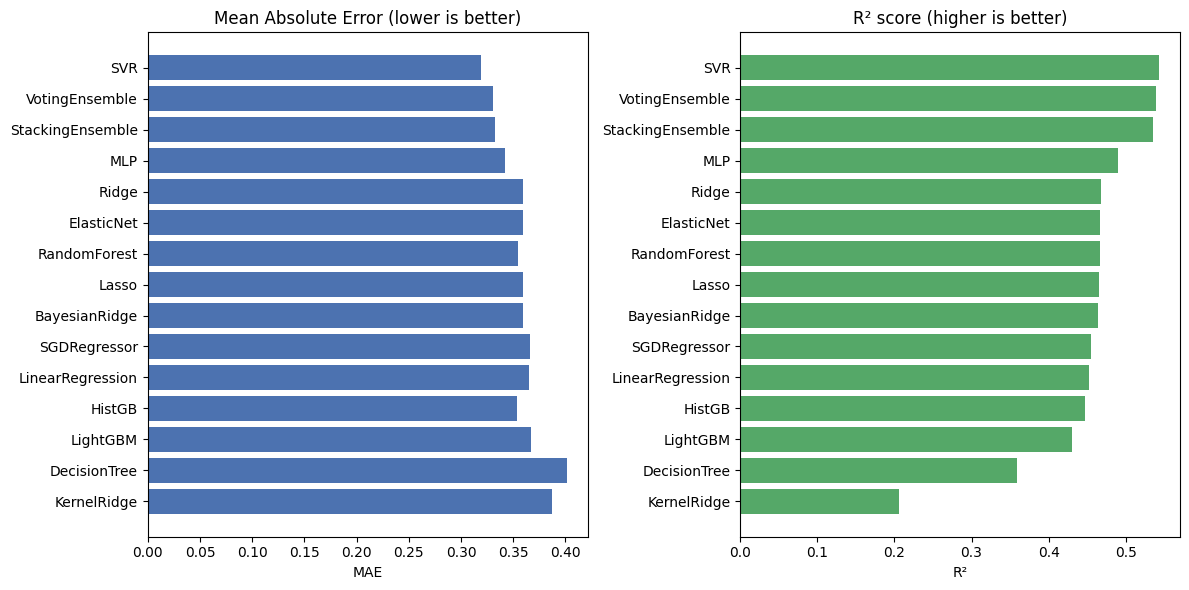

In [ ]:
# bar plots for MAE and R²
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# plot MAE (lower is better)
axes[0].barh(summary["model"], summary["MAE"], color="#4C72B0")
axes[0].invert_yaxis()
axes[0].set_title("Mean Absolute Error (lower is better)")
axes[0].set_xlabel("MAE")

# plot R² (higher is better)
axes[1].barh(summary["model"], summary["R2"], color="#55A868")
axes[1].invert_yaxis()
axes[1].set_title("R² score (higher is better)")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()

On mean absolute error, the ordering is virtually unchanged. SVR still leads, followed closely by the voting and stacking blends, then by the compact MLP and the two penalty based linear models. The small absolute gap between SVR and the best linear alternative is consistent with the idea that most of the predictable variance is already captured by linear terms and that nonlinearity mainly trims occasional outliers rather than wholesale bias. Tree ensembles, once again cluster in the lower third with LightGBM slipping behind its histogram cousin because the small training set penalises its deeper leaf-wise trees.

When looking at the R², we can deduce that SVR and the two ensemble blends explain just over half of the variance in the held out set while linear models plateau around 0.46 to0.48 and tree learners sit in the low forties. A single decision tree breaks the forty percent barrier only by aggressive pruning, and Kernel Ridge, whose RBF bandwidth missed the sweet spot, languishes at roughly 0.20. Taken together, MAE and R² confirm that the SVR family doesn't merely shave a few large residuals (which would move RMSE but not MAE), but it also consistently narrows errors across the board and lifts the share of variance explained. Conversely, models that once promised high expressiveness such as LightGBM and HistGB show that capacity without sufficient data or without content aware features translates to only marginal gains over a well-tuned linear baseline.

In [ ]:
# Only run this if you want files stored in your personal Google Drive
# from google.colab import drive
# from pathlib import Path
# import joblib, shutil

# Mount drive once per session
# drive.mount('/content/drive')

# Reuse the CS958 folder
# SAVE_DIR = Path("/content/drive/MyDrive/CS958")

# Save the fitted pipelines and models
# joblib.dump(rs_svr.best_estimator_, SAVE_DIR / "best_svr.pkl")
# joblib.dump(voter, SAVE_DIR / "voting_ensemble.pkl")
# joblib.dump(stack, SAVE_DIR / "stacking_ensemble.pkl")

# print("models saved to:", SAVE_DIR)

Mounted at /content/drive
dataframe and models saved to: /content/drive/MyDrive/CS958
